In [1]:
import pandas as pd
df = pd.read_csv("C:/Users/tarun/OneDrive/Desktop/deakin/Deakin_Second_Year_T2/SIT307_distinction/sydney_property.csv")
df.head()

,suburb,address,sale_price,property_type,bedrooms,bathrooms,parking,land_size,sale_date,days_on_market,sale_method
0,Blacktown,"25/8-10 Fourth Avenue, Blacktown",415000,Apartment,2,1,1,NaN,16-Sep-26,28.0,private treaty
1,Blacktown,"17 St Pauls Way, Blacktown",828000,Townhouse,3,2,1,103.0,15-Sep-26,103.0,private treaty
2,Blacktown,"3/130 Newton Road, Blacktown",700000,Townhouse,2,1,1,156.0,14-Sep-26,61.0,private treaty
3,Blacktown,"4 & 4A Joseph Street, Blacktown",1340000,House,5,2,5,713.0,14-Sep-26,48.0,private treaty
4,Blacktown,"3/28 Frederick Street, Blacktown",732500,Townhouse,2,1,1,85.0,14-Sep-26,42.0,private treaty


In [2]:
df.shape

(103, 11)

In [3]:
df.isnull().sum()

suburb             0
address            0
sale_price         0
property_type      0
bedrooms           0
bathrooms          0
parking            0
land_size         64
sale_date          4
days_on_market     3
sale_method        0
dtype: int64

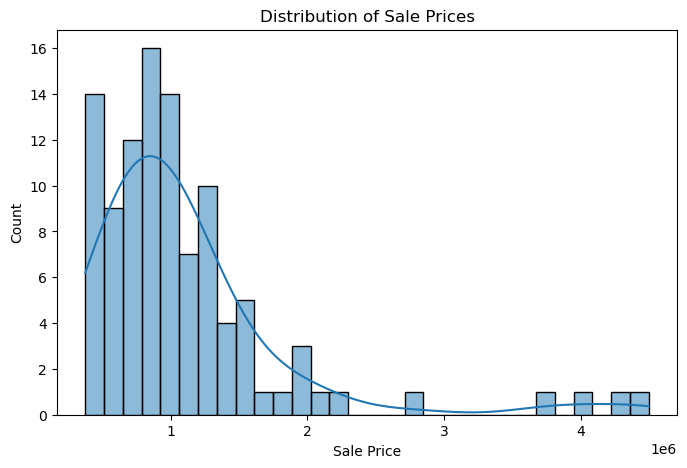

In [4]:
#2
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['sale_price'], bins=30, kde=True)
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price')
plt.show()

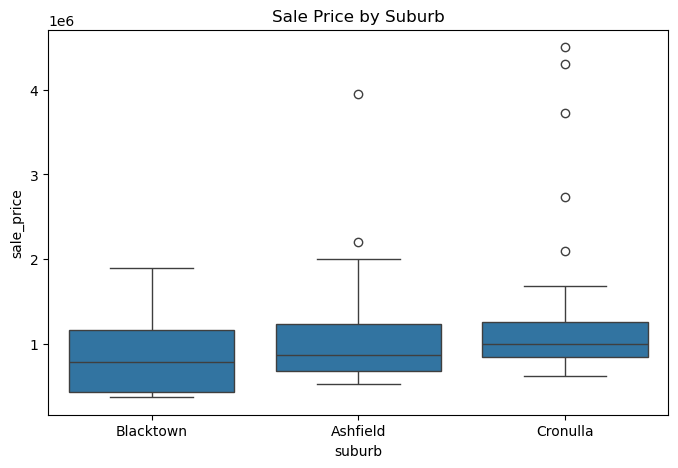

,count,mean,std,min,25%,50%,75%,max
suburb,,,,,,,,
Ashfield,35.0,1.104971e+06,659510.680274,527000.0,680000.0,877500.0,1235000.0,3950000.0
Blacktown,35.0,8.371143e+05,425323.580723,375000.0,442000.0,790000.0,1162000.0,1900000.0
Cronulla,33.0,1.374652e+06,997985.740793,630000.0,850000.0,1005000.0,1256000.0,4500000.0


In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='suburb', y='sale_price', data=df)
plt.title('Sale Price by Suburb')
plt.show()

df.groupby('suburb')['sale_price'].describe()

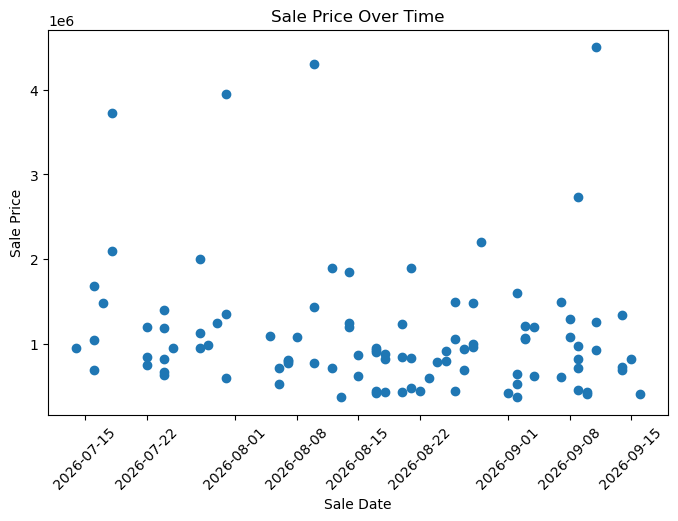

In [6]:
df['sale_date'] = pd.to_datetime(df['sale_date'], format='%d-%b-%y', errors='coerce')

plt.figure(figsize=(8,5))
plt.scatter(df['sale_date'], df['sale_price'])
plt.title('Sale Price Over Time')
plt.xlabel('Sale Date')
plt.ylabel('Sale Price')
plt.xticks(rotation=45)
plt.show()

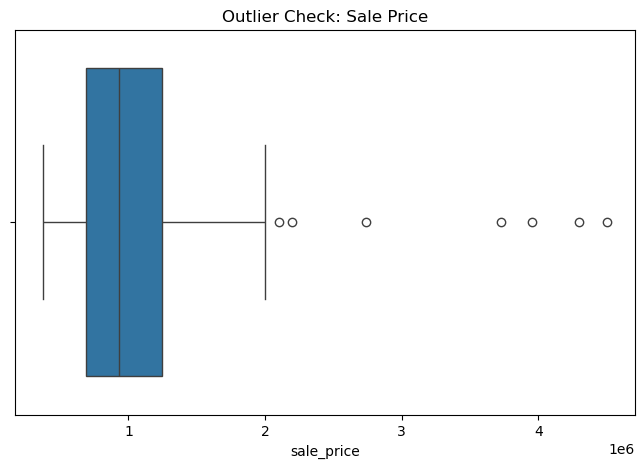

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sale_price', data=df)
plt.title('Outlier Check: Sale Price')
plt.show()

In [8]:
Q1 = df['sale_price'].quantile(0.25)
Q3 = df['sale_price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['sale_price'] < Q1 - 1.5*IQR) | (df['sale_price'] > Q3 + 1.5*IQR)]
print(outliers[['suburb','address','sale_price']])

      suburb                         address  sale_price
44  Ashfield   19 Griffiths Street, Ashfield     2200000
60  Ashfield   128 Victoria Street, Ashfield     3950000
70  Cronulla  22 Chelmsford Avenue, Cronulla     4500000
72  Cronulla      27B Connels Road, Cronulla     2740000
81  Cronulla            2 Bay Lane, Cronulla     4300000
95  Cronulla       2 Ischia Street, Cronulla     3725000
96  Cronulla  2/13-17 Wyanbah Road, Cronulla     2100000


In [9]:
df['bed_bath_ratio'] = df['bedrooms'] / df['bathrooms']

In [10]:
df.head()

,suburb,address,sale_price,property_type,bedrooms,bathrooms,parking,land_size,sale_date,days_on_market,sale_method,bed_bath_ratio
0,Blacktown,"25/8-10 Fourth Avenue, Blacktown",415000,Apartment,2,1,1,NaN,2026-09-16,28.0,private treaty,2.0
1,Blacktown,"17 St Pauls Way, Blacktown",828000,Townhouse,3,2,1,103.0,2026-09-15,103.0,private treaty,1.5
2,Blacktown,"3/130 Newton Road, Blacktown",700000,Townhouse,2,1,1,156.0,2026-09-14,61.0,private treaty,2.0
3,Blacktown,"4 & 4A Joseph Street, Blacktown",1340000,House,5,2,5,713.0,2026-09-14,48.0,private treaty,2.5
4,Blacktown,"3/28 Frederick Street, Blacktown",732500,Townhouse,2,1,1,85.0,2026-09-14,42.0,private treaty,2.0


In [11]:
df['has_land_size'] = df['land_size'].notna().astype(int)

In [12]:
x= df[["suburb","property_type","bedrooms","bathrooms","parking",
    "land_size","has_land_size","days_on_market","sale_method","bed_bath_ratio"]]
y= df["sale_price"]

In [13]:
x

,suburb,property_type,bedrooms,bathrooms,parking,land_size,has_land_size,days_on_market,sale_method,bed_bath_ratio
0,Blacktown,Apartment,2,1,1,NaN,0,28.0,private treaty,2.0
1,Blacktown,Townhouse,3,2,1,103.0,1,103.0,private treaty,1.5
2,Blacktown,Townhouse,2,1,1,156.0,1,61.0,private treaty,2.0
3,Blacktown,House,5,2,5,713.0,1,48.0,private treaty,2.5
4,Blacktown,Townhouse,2,1,1,85.0,1,42.0,private treaty,2.0
...,...,...,...,...,...,...,...,...,...,...
98,Cronulla,Apartment,2,1,1,NaN,0,51.0,private treaty,2.0
99,Cronulla,Apartment,3,2,1,NaN,0,50.0,private treaty,1.5
100,Cronulla,Apartment,1,1,0,NaN,0,34.0,private treaty,1.0
101,Cronulla,Apartment,2,1,1,96.0,1,174.0,private treaty,2.0


In [14]:
#3
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

impute_cols=["days_on_market","land_size"]
trf1= ColumnTransformer([
    ("trf1", SimpleImputer(strategy="median"), impute_cols)
], remainder="passthrough", verbose_feature_names_out=False)
trf1.set_output(transform="pandas")

numeric_cols=["bedrooms","bathrooms","parking","land_size","days_on_market","bed_bath_ratio"]
trf2= ColumnTransformer([
    ("trf2", MinMaxScaler(), numeric_cols)], remainder="passthrough", verbose_feature_names_out=False)
trf2.set_output(transform="pandas")

ohe_cols=["suburb","property_type","sale_method"]
trf3= ColumnTransformer([
    ("trf3", OneHotEncoder(sparse_output=False), ohe_cols)], remainder="passthrough", verbose_feature_names_out=False)
trf3.set_output(transform="pandas")

pipe_lr=Pipeline([
    ("trf1", trf1),
    ("trf2", trf2),
    ("trf3", trf3),
    ("model", LinearRegression())
])

pipe_rf=Pipeline([
    ("trf1", trf1),
    ("trf2", trf2),
    ("trf3", trf3),
    ("model", RandomForestRegressor(random_state=42))
])

pipe_knn=Pipeline([
    ("trf1", trf1),
    ("trf2", trf2),
    ("trf3", trf3),
    ("model", KNeighborsRegressor())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "KNN": pipe_knn
}

for name, pipe in models.items():
    scores = cross_val_score(pipe, x_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse = (-scores.mean()) ** 0.5
    print(f"{name}: RMSE = {rmse:.2f}")

Linear Regression: RMSE = 485652.62
Random Forest: RMSE = 583342.49
KNN: RMSE = 563266.76


In [24]:
from sklearn.model_selection import cross_val_score
results = []

for name, pipe in models.items():
    rmse_scores = cross_val_score(pipe, x_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    mae_scores = cross_val_score(pipe, x_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(pipe, x_train, y_train, cv=kf, scoring='r2')

    results.append({
        'Model': name,
        'Mean RMSE': -rmse_scores.mean(),
        'Mean MAE': -mae_scores.mean(),
        'Mean R2': r2_scores.mean()})
    
cv_results = pd.DataFrame(results)
print(cv_results)

               Model      Mean RMSE       Mean MAE   Mean R2
0  Linear Regression  462693.935961  314908.752541  0.451436
1      Random Forest  494885.343785  295761.750613  0.482993
2                KNN  481570.579718  304185.367647  0.559406


In [25]:
from sklearn.metrics import mean_squared_error
for name, pipe in models.items():
    pipe.fit(x_train, y_train)
    train_pred = pipe.predict(x_train)
    train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
    print(f"{name}: Train RMSE = {train_rmse:.2f}")

Linear Regression: Train RMSE = 349154.30
Random Forest: Train RMSE = 192318.75
KNN: Train RMSE = 383486.22


In [26]:
import numpy as np
from sklearn.model_selection import GridSearchCV
param_grid_rf= {"model__n_estimators": [50, 100, 200],
    "model__max_depth": [5, 10, 15, None]}
grid_rf= GridSearchCV(pipe_rf, param_grid_rf, cv=kf, scoring='neg_mean_squared_error')
grid_rf.fit(x_train,y_train)

print("best params: ", grid_rf.best_params_)
print("best score: ", np.sqrt(-grid_rf.best_score_))

best params:  {'model__max_depth': 10, 'model__n_estimators': 200}
best score:  578893.8318744344


In [27]:
param_grid_knn = {'model__n_neighbors': [3, 5, 7, 9, 11]}
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=kf, scoring='neg_mean_squared_error')
grid_knn.fit(x_train, y_train)

print("best params: ", grid_knn.best_params_)
print("best score: ", np.sqrt(-grid_knn.best_score_))

best params:  {'model__n_neighbors': 3}
best score:  549184.8459084521


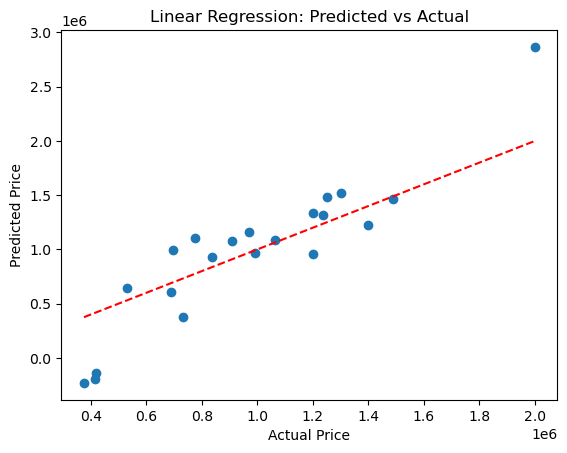

In [28]:
import matplotlib.pyplot as plt
pipe_lr.fit(x_train, y_train)
y_pred = pipe_lr.predict(x_test)

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Predicted vs Actual')
plt.show()

In [29]:
#4
pipe_lr.fit(x_train, y_train)
y_pred = pipe_lr.predict(x_test)

results = x_test.copy()
results['actual_price'] = y_test.values
results['predicted_price'] = y_pred
results['error'] = results['actual_price'] - results['predicted_price']
results['abs_error'] = results['error'].abs()

top5_errors = results.sort_values('abs_error', ascending=False).head(5)
print(top5_errors[['suburb', 'property_type', 'bedrooms', 'bathrooms', 'land_size',
                     'actual_price', 'predicted_price', 'error']])

       suburb property_type  bedrooms  bathrooms  land_size  actual_price  \
62   Ashfield         House         6          3      563.0       2000000   
0   Blacktown     Apartment         2          1        NaN        415000   
12  Blacktown     Apartment         1          1        NaN        375000   
30  Blacktown     Apartment         2          1        NaN        419000   
4   Blacktown     Townhouse         2          1       85.0        732500   

    predicted_price          error  
62     2.867000e+06 -866999.962005  
0     -1.923925e+05  607392.496282  
12    -2.312920e+05  606292.030697  
30    -1.424837e+05  561483.695854  
4      3.803475e+05  352152.540929  


In [30]:
#5
import joblib
pipe_lr.fit(x_train, y_train)
joblib.dump(pipe_lr, 'housing_price_model.pkl')

['housing_price_model.pkl']